# Сокращение размерности

В каждом из заданий:
* Обучите два классификатора (svm и огистическую регрессию на датасете данном ниже) в датасете размерность из 30 признаков
* Попребирайте различное количество итоговых размерностей и постройте графики качества от количества размерностей. Выведите обе модели на одном графике в каждой заадче

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import decomposition, datasets, svm
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import SequentialFeatureSelector

np.random.seed(5)
dataset = datasets.load_breast_cancer()
X = dataset.data
y = dataset.target
dimensions = range(1, 30)

# Forward selection (2pts)

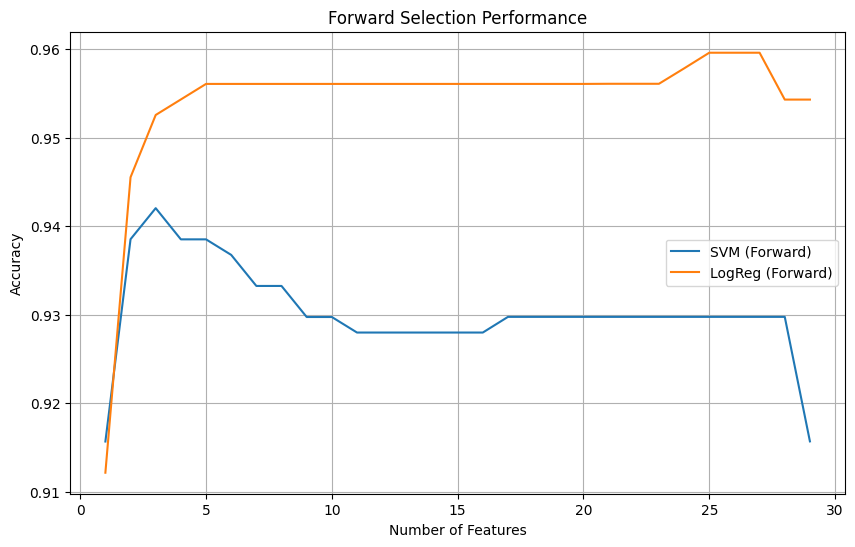

In [11]:
svc_scores_forward = []
lr_scores_forward = []

for k in dimensions:
    sfs_lr = SequentialFeatureSelector(LogisticRegression(max_iter=5000), n_features_to_select=k, direction='forward')
    X_lr = sfs_lr.fit_transform(X, y)
    lr_scores_forward.append(np.mean(cross_val_score(LogisticRegression(max_iter=5000), X_lr, y, cv=5)))

    sfs_svc = SequentialFeatureSelector(svm.SVC(), n_features_to_select=k, direction='forward')
    X_svc = sfs_svc.fit_transform(X, y)
    svc_scores_forward.append(np.mean(cross_val_score(svm.SVC(), X_svc, y, cv=5)))

plt.figure(figsize=(10, 6))
plt.plot(dimensions, svc_scores_forward, label='SVM (Forward)')
plt.plot(dimensions, lr_scores_forward, label='LogReg (Forward)')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.title('Forward Selection Performance')
plt.legend()
plt.grid(True)
plt.show()

# Backward elimination (2pts)

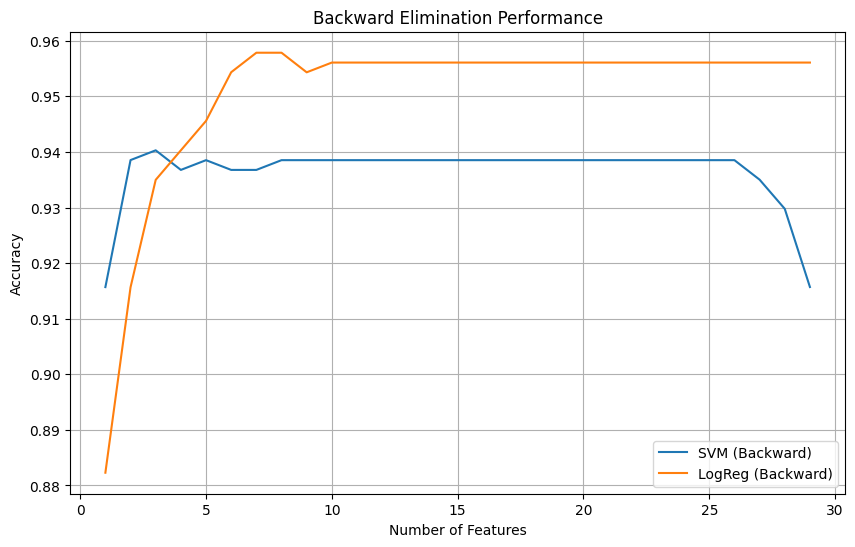

In [12]:
svc_scores_backward = []
lr_scores_backward = []

for k in dimensions:
    sfs_lr = SequentialFeatureSelector(LogisticRegression(max_iter=5000), n_features_to_select=k, direction='backward')
    X_lr = sfs_lr.fit_transform(X, y)
    lr_scores_backward.append(np.mean(cross_val_score(LogisticRegression(max_iter=5000), X_lr, y, cv=5)))

    sfs_svc = SequentialFeatureSelector(svm.SVC(), n_features_to_select=k, direction='backward')
    X_svc = sfs_svc.fit_transform(X, y)
    svc_scores_backward.append(np.mean(cross_val_score(svm.SVC(), X_svc, y, cv=5)))

plt.figure(figsize=(10, 6))
plt.plot(dimensions, svc_scores_backward, label='SVM (Backward)')
plt.plot(dimensions, lr_scores_backward, label='LogReg (Backward)')
plt.xlabel('Number of Features')
plt.ylabel('Accuracy')
plt.title('Backward Elimination Performance')
plt.legend()
plt.grid(True)
plt.show()

# PCA (2 pts)


### EM алгоритм

Оставлю это тут просто чтобы пугать людей


$$
\log p(x|\theta) = \int q(z)\log p(x|\theta)dz = \int q(z)\log\dfrac{p(x,z|\theta)}{p(z|x,\theta)}dz = \int q(z)\log\dfrac{p(x,z|\theta)}{q(z)}dz+\int q(z)\log\dfrac{q(z)}{p(z|x,\theta)}dz = \mathcal{L}(q,\theta)+KL(q(z)|p(z|x,\theta))
$$

** E-step **
$$ q(z)^{(n+1)} = p(z|x,\theta^{(n)}) $$
** M-step **
$$ \theta^{(n+1)} = \max\limits_{\theta} \mathcal{L}(q^{(n+1)},\theta) $$

Обучите два классификатора (svm и огистическую регрессию на датасете данном ниже) в датасете размерность из 30 признаков. Попребирайте различное количество итоговых размерностей (до которых будет сокращать PCA) и постройте графики для обоих классификаторов. Сделайте выводы.

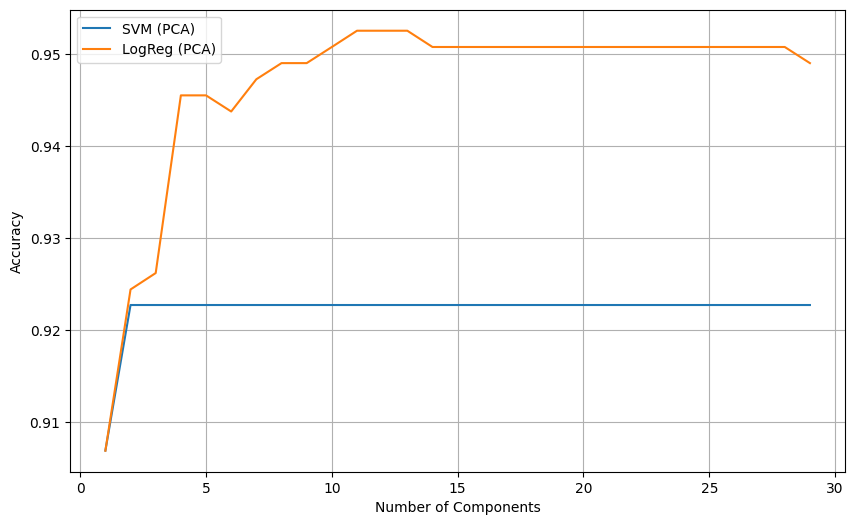

In [4]:
svc_scores_pca = []
lr_scores_pca = []
dimensions = range(1, 30)

for k in dimensions:
    pca = decomposition.PCA(n_components=k)
    X_pca = pca.fit_transform(X)

    svc_score = np.mean(cross_val_score(svm.SVC(), X_pca, y, cv=5))
    lr_score = np.mean(cross_val_score(LogisticRegression(max_iter=5000), X_pca, y, cv=5))

    svc_scores_pca.append(svc_score)
    lr_scores_pca.append(lr_score)

plt.figure(figsize=(10, 6))
plt.plot(dimensions, svc_scores_pca, label='SVM (PCA)')
plt.plot(dimensions, lr_scores_pca, label='LogReg (PCA)')
plt.xlabel('Number of Components')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

#  Выводы (1pts)

In [ ]:
PCA обучается очень сильно быстрее регрессии.
Однако при PCA из-за сжатия нам сильно сложнее понять, как именно параметры влияют на результат модели.
Максимальная точность достигается при использовании 5-15 признаков, а дальше точность не растет, а в районе 25-30 даже падает, что указывает на переобучение.
Как ни странно, logreg показал себя лучше svm практически везде.